# Course NIGK21007U - Integrated Water Resources Modelling
## Reading and Processing dfs3 files

dfs3 is a proprietary binary file format by DHI. It is used to store time variable datasets with three spatial dimensions, for instance water content or hydraulic head, so the dataset has 4 dimensions in total, time, x, y and z. This notebook shows you how to read and process such files in python.

First, import all necessary python packages:

In [1]:
import mikeio
from mikeio import Dfs3
import matplotlib.pyplot as plt
import geopandas as gpd

mikeio is a python library made by DHI that enables interaction with dfs file format. matplotlib is a plotting and visualization package. geopandas is a python library to read, write, and manipulate shapefiles.

Next, specify the name of the dfs3 file you want to read. **r'...'** makes sure that the filename is read as a raw string and backslashes are not interpreted as line breaks. Obviously, you need to adjust path and file name so that they point to an existing dfs3 file on your system.

In [2]:
my_file_name = r'c:\Users\vpk410\Documents\DK1\DK1_HIPmodels\Setup\DK1_HIP_500m.she - Result Files\DK1_HIP_500m_3DSZ.dfs3'

Next, open the file to get a Dfs3 object. After this step, metadata is available but data isn't loaded yet.

In [4]:
dfs = Dfs3(my_file_name)

Inspect file properties (e.g., number of time steps, items):

In [5]:
print(f"Number of time steps: {dfs.n_timesteps}")
print(f"Item names: {[item.name for item in dfs.items]}")

Number of time steps: 1750
Item names: ['head elevation in saturated zone']


Define an item you are interested in:

In [6]:
my_item = r'head elevation in saturated zone'

Read the Dataset (ds):

In [7]:
ds = mikeio.read(my_file_name, items=[my_item])

Extract the time indices from the file:

In [8]:
time_array_datetime = ds.time.values
print(time_array_datetime)

['1989-01-02T06:00:00' '1989-01-09T06:00:00' '1989-01-16T06:00:00' ...
 '2022-06-27T06:00:00' '2022-07-04T06:00:00' '2022-07-11T06:00:00']


Get the unit of the item - take not of the use of repr here - unit itself is a DHI code.

In [9]:
unit = repr(ds[my_item].unit)
print(unit)

meter


Get the DataArray for the item of interest. The shape of the underlying data is (time, x, y).

In [10]:
data_array = ds[my_item]
print(data_array.shape)

(1750, 11, 410, 270)


Make a time series plot at one specific place. First define the spatial indeces of the place of interest:

In [11]:
x_idx = 200
y_idx = 200
z_idx = 0 # Note that layer 0 is the deepest layer!! Not the first layer from the top!

Next, extract the time series using the indices (Time, Y, X). The colon `:` for the time axis ensures we get ALL time steps.

In [12]:
time_series_values = data_array.values[:, z_idx, y_idx, x_idx]

Now make a time series plot:

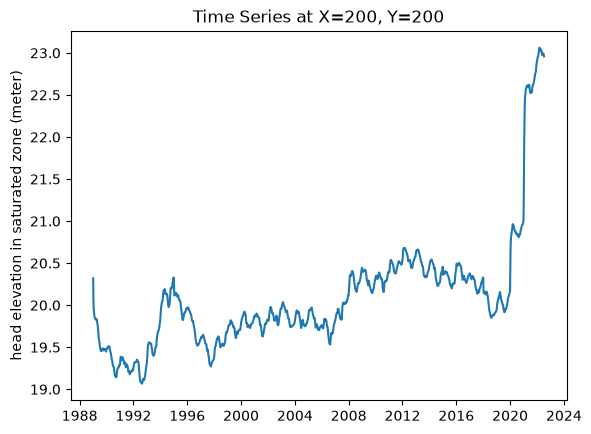

In [13]:
fig, ax = plt.subplots()
ax.plot(time_array_datetime, time_series_values)
ax.set_ylabel(f"{my_item}" + ' (' + unit + ')')
ax.set_title(f"Time Series at X={x_idx}, Y={y_idx}")
plt.show()

Now make a time layer time slice plot, i.e. a map for one specific time and one specific layer. First, define the time and layer indeces and then extract the time slice values from the dataset:

In [14]:
t_idx = 1700
z_idx = 0
layer_values = data_array.values[t_idx, z_idx, :, :]

Extract X and Y coordinates from the DataArray geometry. For a rectilinear grid (DFS2), these are 1D arrays of center coordinates:

In [15]:
x_coords = data_array.geometry.x
y_coords = data_array.geometry.y

Make the plot

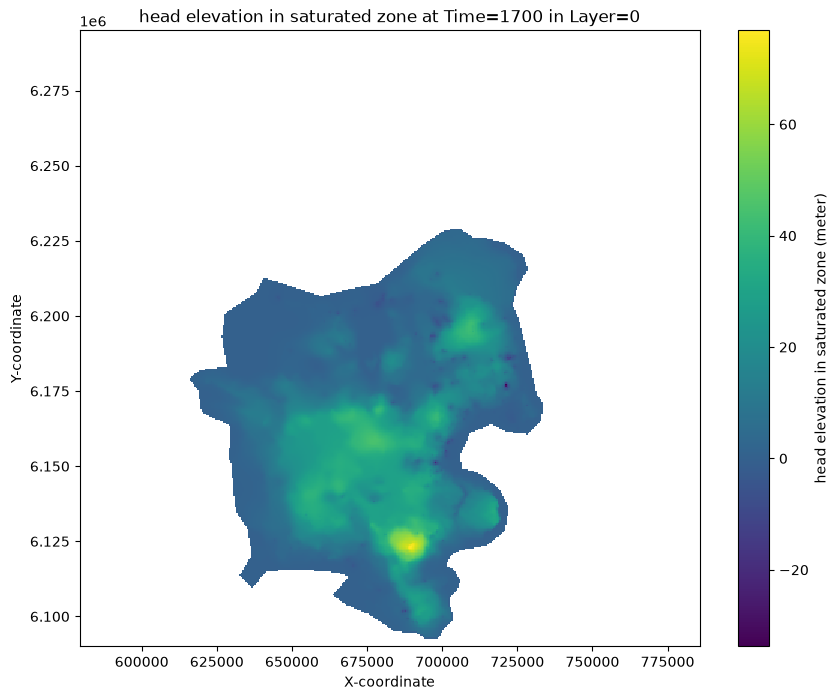

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

# Use pcolormesh to create the colour plot
# Note: X and Y coordinates should be passed as 2D arrays (using np.meshgrid) 
# or pcolormesh will infer the corner points. We use the simpler method below.

# Plotting the data. We transpose the Y coordinates to match the (Y, X) data shape
c = ax.pcolormesh(x_coords, y_coords, layer_values, 
                  shading='auto', # Recommended for rectilinear grids
                  cmap='viridis')  # Choose a nice colour map (viridis, jet, coolwarm, etc.)

# Add a colour bar to show the scale
cbar = fig.colorbar(c, ax=ax)

# Clean up and label the plot
ax.set_title(f"{data_array.name} at Time={t_idx} in Layer={z_idx}")
ax.set_xlabel("X-coordinate")
ax.set_ylabel("Y-coordinate")

    
cbar.set_label(f"{my_item}" + ' (' + unit + ')')

plt.axis('equal') # Ensure the aspect ratio is correct for the map
plt.show()

Now, make a layer plot and overlay a shapefile. First define the shapefile and read it with geopandas:

In [18]:
shapefile_path = r'c:\Users\vpk410\Documents\DK1\MapsDK\DKDomains2013\kort10_land.shp'
gdf = gpd.read_file(shapefile_path)

Make the plot:

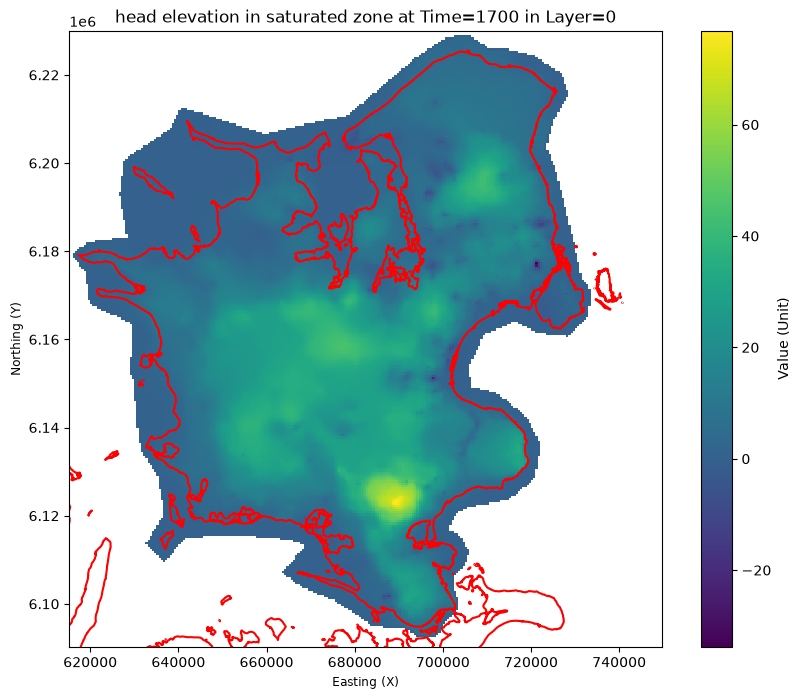

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

# --- BASE LAYER (DFS3 Data) ---
# Use pcolormesh to create the colour plot
c = ax.pcolormesh(x_coords, y_coords, layer_values, 
                  shading='auto',
                  cmap='viridis',
                  zorder=1) # zorder=1 ensures it is plotted first

# Add color bar (optional but recommended)
cbar = fig.colorbar(c, ax=ax, label="Value (Unit)") # Update label as needed

# --- OVERLAY LAYER (Shapefile) ---
# Use GeoPandas plot method, passing the existing axes (ax)
gdf.plot(ax=ax, 
         edgecolor='red', # Color of the boundary line
         facecolor='none', # Make the interior transparent
         linewidth=1.5,
         zorder=2) # zorder=2 ensures it is plotted on top

# Determine the boundaries for the X-axis
min_x = x_coords.min()
max_x = x_coords.max()

# Determine the boundaries for the Y-axis
min_y = y_coords.min()
max_y = y_coords.max()

# Restrict X-axis limits using the min/max coordinates
ax.set_xlim(min_x, max_x)

# Restrict Y-axis limits using the min/max coordinates
ax.set_ylim(min_y, 6230000)

# Set Plot Aesthetics
ax.set_title(f"{data_array.name} at Time={t_idx} in Layer={z_idx}")
ax.set_xlabel("Easting (X)")
ax.set_ylabel("Northing (Y)")
# plt.axis('equal') # Maintain map aspect ratio
plt.show()